Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': None, 'rf__max_depth': 10}
Best Cross-Validation Accuracy: 0.698
[[14124  5015]
 [ 4299  8156]]
              precision    recall  f1-score   support

       False       0.77      0.74      0.75     19139
        True       0.62      0.65      0.64     12455

    accuracy                           0.71     31594
   macro avg       0.69      0.70      0.69     31594
weighted avg       0.71      0.71      0.71     31594

Test Accuracy: 0.705


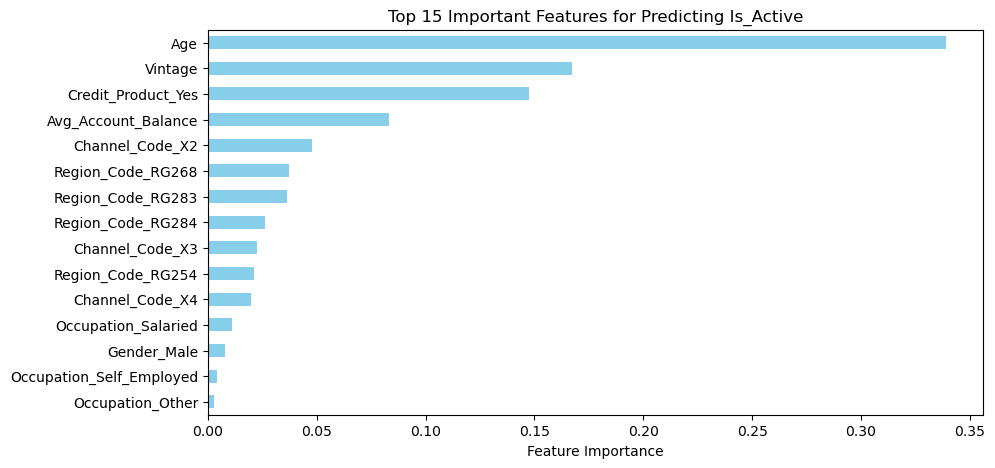

In [4]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv("Test_Data.csv")

# Drop ID column as it is not useful
df = df.drop("ID", axis=1)

# Convert categorical variables into numeric using get_dummies
df_dummies = pd.get_dummies(df, drop_first=True)

# Create X and y arrays
X = df_dummies.drop("Is_Active_Yes", axis=1).values
y = df_dummies["Is_Active_Yes"].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


# Build the steps
steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Handle missing values
    ("scaler", StandardScaler()),                          # Scale numerical features
    ("rf", RandomForestClassifier(random_state=42))        # Random Forest model
]

# Create the pipeline
pipeline = Pipeline(steps)

# Define parameter grid for Random Forest
params = {
    "rf__n_estimators": [50, 100, 150, 200],
    "rf__max_depth": [5, 10, 15, 20, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", None]
}

# Create RandomizedSearchCV object
rf_random = RandomizedSearchCV(
    pipeline, param_distributions=params,
    n_iter=20, cv=5, random_state=42, n_jobs=-1, verbose=1
)

# Fit the model
rf_random.fit(X_train, y_train)

# Print best parameters and best accuracy
print("Best Parameters: {}".format(rf_random.best_params_))
print("Best Cross-Validation Accuracy: {:.3f}".format(rf_random.best_score_))


# Predict on the test set
y_pred = rf_random.predict(X_test)

# Print confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Print test accuracy
print("Test Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))

# FEATURE IMPORTANCE PLOT
# Extract feature importances
best_model = rf_random.best_estimator_.named_steps["rf"]
importances = best_model.feature_importances_
features = df_dummies.drop("Is_Active_Yes", axis=1).columns

# Create DataFrame for visualization
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot top 15 important features
plt.figure(figsize=(10,5))
feat_imp.head(15).plot(kind="barh", color="skyblue")
plt.title("Top 15 Important Features for Predicting Is_Active")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()


Lasso Coefficients:
[ 0.01771197  0.01537809  0.00288889  0.0031931  -0.         -0.00132571
  0.         -0.00064109  0.         -0.         -0.         -0.
  0.         -0.          0.         -0.         -0.         -0.
  0.         -0.          0.          0.01070004 -0.00168226 -0.00083655
  0.         -0.         -0.          0.          0.00149983  0.
 -0.         -0.          0.         -0.          0.00086179 -0.
  0.00863517  0.0100187  -0.         -0.00260047  0.          0.07669501
  0.08996609  0.03696901 -0.08402316]

Selected Features (Non-zero coefficients):
Age                    0.017712
Vintage                0.015378
Avg_Account_Balance    0.002889
Gender_Male            0.003193
Region_Code_RG252     -0.001326
Region_Code_RG254     -0.000641
Region_Code_RG268      0.010700
Region_Code_RG269     -0.001682
Region_Code_RG270     -0.000837
Region_Code_RG275      0.001500
Region_Code_RG281      0.000862
Region_Code_RG283      0.008635
Region_Code_RG284      0.010019
Occ

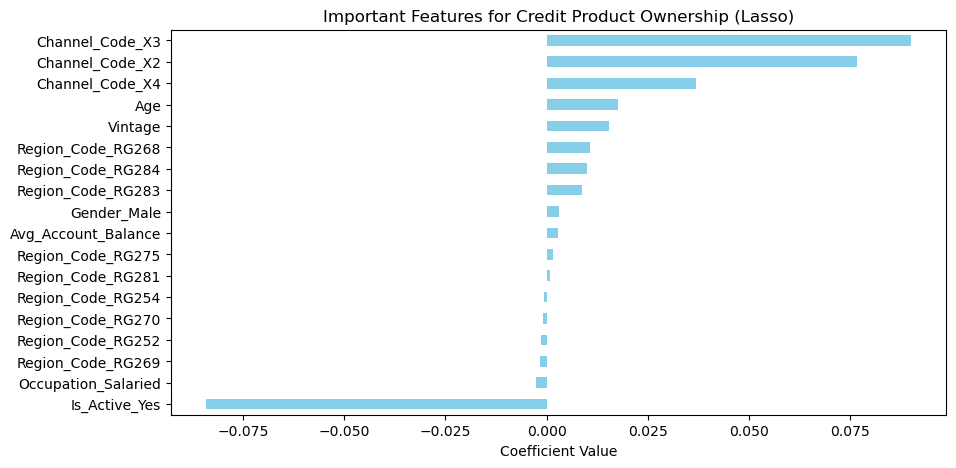

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

df = pd.read_csv("Test_Data.csv")

# Drop ID column (not useful for prediction)
df = df.drop("ID", axis=1)

# Drop missing target values
df = df.dropna(subset=["Credit_Product"])

# Converting categorical data to numeric using get_dummies
df_dummies = pd.get_dummies(df, drop_first=True)

# Create X and y arrays
X = df_dummies.drop("Credit_Product_Yes", axis=1).values
y = df_dummies["Credit_Product_Yes"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate Lasso model
lasso = Lasso(alpha=0.01, random_state=42)

# Fit the model to the training data
lasso.fit(X_train_scaled, y_train)

# Extract coefficients
lasso_coef = lasso.coef_

# Print all coefficients
print("Lasso Coefficients:")
print(lasso_coef)

# Converting to Series for interpretation
feature_names = df_dummies.drop("Credit_Product_Yes", axis=1).columns
lasso_features = pd.Series(lasso_coef, index=feature_names)

# Print only non-zero coefficients
print("\nSelected Features (Non-zero coefficients):")
print(lasso_features[lasso_features != 0])

# Visualize Feature Importance
plt.figure(figsize=(10,5))
lasso_features[lasso_features != 0].sort_values().plot(kind="barh", color="skyblue")
plt.title("Important Features for Credit Product Ownership (Lasso)")
plt.xlabel("Coefficient Value")
plt.show()


In [9]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv("Test_Data.csv")

# Drop ID column (not useful)
df = df.drop("ID", axis=1)

# Drop rows where target variable (Credit_Product) is missing
df = df.dropna(subset=["Credit_Product"])

# Convert categorical data to numeric using get_dummies
df_dummies = pd.get_dummies(df, drop_first=True)

# Keeping only the 18 Lasso-selected features
selected_features = [
    "Age",
    "Vintage",
    "Avg_Account_Balance",
    "Gender_Male",
    "Region_Code_RG252",
    "Region_Code_RG254",
    "Region_Code_RG268",
    "Region_Code_RG269",
    "Region_Code_RG270",
    "Region_Code_RG275",
    "Region_Code_RG281",
    "Region_Code_RG283",
    "Region_Code_RG284",
    "Occupation_Salaried",
    "Channel_Code_X2",
    "Channel_Code_X3",
    "Channel_Code_X4",
    "Is_Active_Yes"
]

# Creating X and y arrays
X = df_dummies[selected_features].values
y = df_dummies["Credit_Product_Yes"].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
]
pipeline = Pipeline(steps)

params = {
    "logreg__C": np.linspace(0.001, 10, 50),
    "logreg__solver": ["liblinear", "saga"],     # ✅ compatible solvers
    "logreg__penalty": ["l1", "l2"],             # ✅ both allowed now
    "logreg__class_weight": ["balanced", None]
}

# Creating RandomizedSearchCV object
logreg_cv = RandomizedSearchCV(
    pipeline,
    param_distributions=params,
    n_iter=30,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the model on the training data
logreg_cv.fit(X_train, y_train)

# -----------------------------------------------------------
# Evaluate model
# -----------------------------------------------------------

print("Best Parameters:", logreg_cv.best_params_)
print("Best Cross-Validation Accuracy: {:.3f}".format(logreg_cv.best_score_))

# Predict on test data
y_pred = logreg_cv.predict(X_test)

# Confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Test Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'logreg__solver': 'saga', 'logreg__penalty': 'l2', 'logreg__class_weight': None, 'logreg__C': np.float64(0.20506122448979594)}
Best Cross-Validation Accuracy: 0.702
[[15866  2616]
 [ 5724  3631]]
              precision    recall  f1-score   support

       False       0.73      0.86      0.79     18482
        True       0.58      0.39      0.47      9355

    accuracy                           0.70     27837
   macro avg       0.66      0.62      0.63     27837
weighted avg       0.68      0.70      0.68     27837

Test Accuracy: 0.700



Logistic Regression Results:
               precision    recall  f1-score   support

 Entrepreneur       0.04      0.67      0.07       323
        Other       0.64      0.47      0.54      9039
     Salaried       0.69      0.88      0.77      9274
Self_Employed       0.78      0.43      0.55     12958

     accuracy                           0.58     31594
    macro avg       0.54      0.61      0.48     31594
 weighted avg       0.70      0.58      0.61     31594

Accuracy: 0.576

Decision Tree Results:
               precision    recall  f1-score   support

 Entrepreneur       0.07      0.07      0.07       323
        Other       0.53      0.53      0.53      9039
     Salaried       0.62      0.62      0.62      9274
Self_Employed       0.70      0.70      0.70     12958

     accuracy                           0.62     31594
    macro avg       0.48      0.48      0.48     31594
 weighted avg       0.62      0.62      0.62     31594

Accuracy: 0.621

Random Forest Results:
    

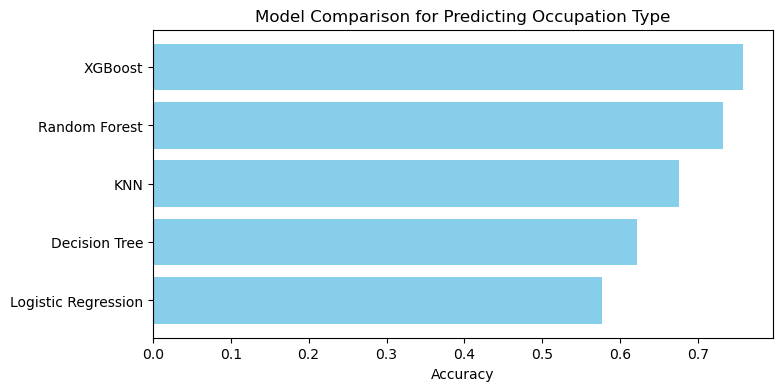

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("Test_Data.csv")

# Drop ID (not useful)
df = df.drop("ID", axis=1)

# Drop rows where Occupation (target) is missing
df = df.dropna(subset=["Occupation"])

# Convert categorical variables into numeric using get_dummies
df_dummies = pd.get_dummies(df, drop_first=True)

# Encode Occupation into numeric labels
le = LabelEncoder()
y = le.fit_transform(df["Occupation"])  # target
X = df_dummies.drop(
    [col for col in df_dummies.columns if col.startswith("Occupation_")], axis=1
).values

# Split data into train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

classifiers = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    ("Random Forest", RandomForestClassifier(class_weight="balanced", random_state=42)),
    ("XGBoost", XGBClassifier(eval_metric="mlogloss", random_state=42)),  # auto-handles imbalance internally
    ("KNN", KNeighborsClassifier())
]

# LOOP THROUGH MODELS
results = []

for name, model in classifiers:
    # Create pipeline
    steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("clf", model)
    ]
    pipeline = Pipeline(steps)
    
    # Fit and predict
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))
    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    print(f"Accuracy: {acc:.3f}")


# COMPARE RESULTS
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

print("\n\nModel Comparison:")
print(results_df)

# Plot accuracies
plt.figure(figsize=(8,4))
plt.barh(results_df["Model"], results_df["Accuracy"], color="skyblue")
plt.xlabel("Accuracy")
plt.title("Model Comparison for Predicting Occupation Type")
plt.gca().invert_yaxis()
plt.show()



Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86     13345
           1       0.55      0.49      0.52      8753
           2       0.60      0.63      0.61      8781
           3       0.28      0.96      0.43       715

    accuracy                           0.68     31594
   macro avg       0.58      0.72      0.61     31594
weighted avg       0.71      0.68      0.69     31594

Accuracy: 0.680

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     13345
           1       0.49      0.50      0.50      8753
           2       0.53      0.52      0.53      8781
           3       0.41      0.42      0.42       715

    accuracy                           0.65     31594
   macro avg       0.57      0.57      0.57     31594
weighted avg       0.65      0.65      0.65     31594

Accuracy: 0.646

Random Forest Results:
              precis

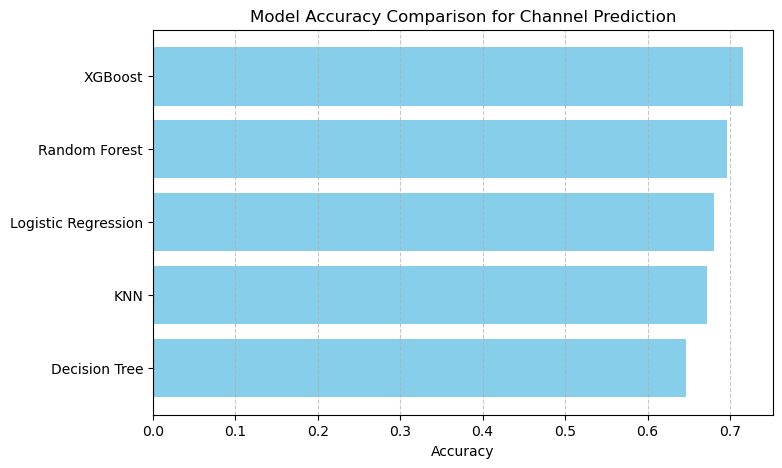

In [4]:

# PREDICTING MARKETING CHANNEL USING MULTIPLE MODELS

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

df = pd.read_csv("Test_Data.csv")
df = df.drop("ID", axis=1)

# Encode target (Channel_Code)
le = LabelEncoder()
df["Channel_Code"] = le.fit_transform(df["Channel_Code"])

# Convert categorical variables into dummy form
df_dummies = pd.get_dummies(df, drop_first=True)

# Define X and y
X = df_dummies.drop("Channel_Code", axis=1)
y = df["Channel_Code"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss", 
        random_state=42,
    )
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {acc:.3f}")

# Summarize and visualize accuracy comparison
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Comparison Summary:")
print(results_df)

# Bar chart for visual comparison
plt.figure(figsize=(8,5))
plt.barh(results_df.index, results_df['Accuracy'], color='skyblue')
plt.title("Model Accuracy Comparison for Channel Prediction")
plt.xlabel("Accuracy")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


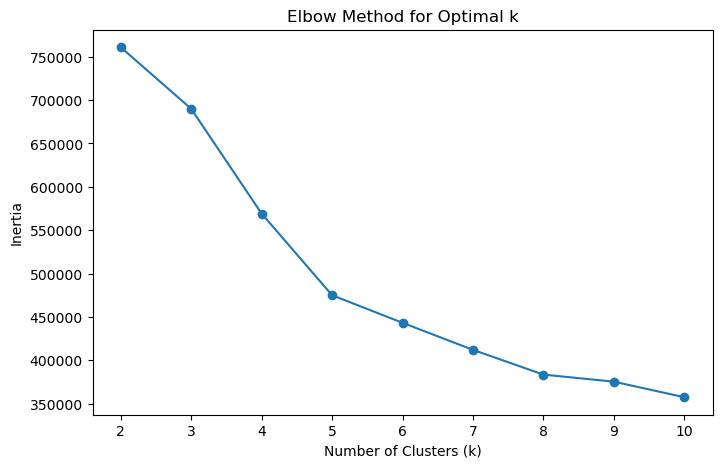

In [1]:

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Test_Data.csv")

# Drop ID column
df = df.drop("ID", axis=1)

# Convert categorical features to numeric
df_dummies = pd.get_dummies(df, drop_first=True)

# Select features for clustering
features = [
    'Age',
    'Vintage',
    'Avg_Account_Balance',
    'Is_Active_Yes',
    'Credit_Product_Yes',
    'Gender_Male',
    'Channel_Code_X2',
    'Channel_Code_X3',
    'Channel_Code_X4'
]

X = df_dummies[features]

# Elbow Method (Imputer + Scaler + KMeans)
inertia = []
K = range(2, 11)

for k in K:
    km = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42))
    ])
    km.fit(X)
    inertia.append(km['kmeans'].inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.show()



📊 Cluster Summary (numeric averages):
           Age  Vintage  Avg_Account_Balance  Count
Cluster                                            
0        29.94    22.53            899586.62  43235
1        50.46    37.72            946364.51  27919
2        47.70    56.03           3841248.08   5461
3        57.71    90.60           1155245.18  28697

🏷️ Most Common Categorical Values per Cluster:
         Gender Region_Code     Occupation Channel_Code Credit_Product  \
Cluster                                                                  
0        Female       RG254       Salaried           X1             No   
1          Male       RG268  Self_Employed           X2             No   
2          Male       RG268  Self_Employed           X3             No   
3          Male       RG268  Self_Employed           X3             No   

        Is_Active  
Cluster            
0              No  
1              No  
2              No  
3             Yes  


C:\Users\manan\Documents\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


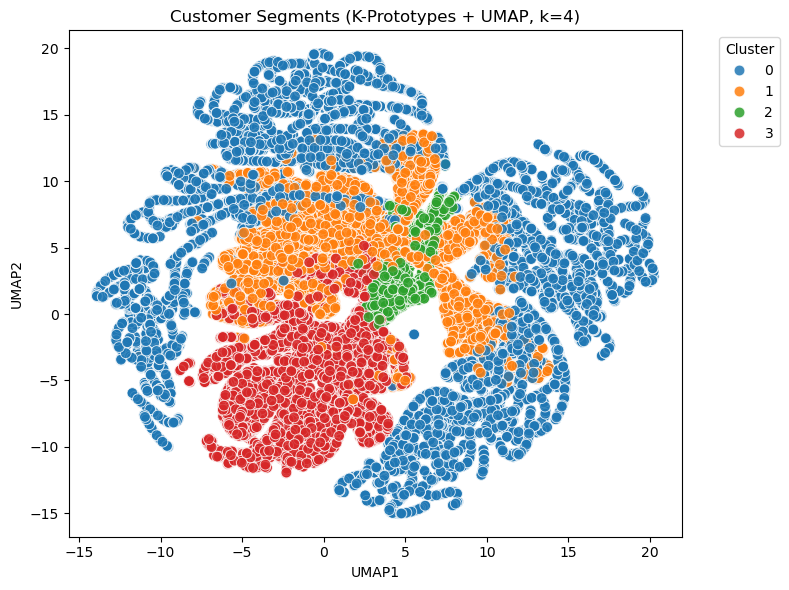

In [1]:

# CUSTOMER SEGMENTATION USING K-PROTOTYPES + UMAP

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from kmodes.kprototypes import KPrototypes
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("Test_Data.csv")

# Drop ID column (not useful for clustering)
df = df.drop("ID", axis=1)

# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()


# Numeric preprocessing: impute missing values + scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: impute missing values only
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine both using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


X_preprocessed = preprocessor.fit_transform(df)

# Convert to DataFrame for clarity
processed_cols = num_cols + cat_cols
X_df = pd.DataFrame(X_preprocessed, columns=processed_cols)

# Find categorical indices (needed for K-Prototypes)
cat_indices = [X_df.columns.get_loc(c) for c in cat_cols]


k = 4  # from elbow method
kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42)
clusters = kproto.fit_predict(X_df.to_numpy(), categorical=cat_indices)

# Add cluster labels to DataFrame
df['Cluster'] = clusters


# Numeric summary (mean values)
cluster_summary = df.groupby('Cluster')[num_cols].mean()
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index().values

print("\n Cluster Summary (numeric averages):")
print(cluster_summary.round(2))

# Categorical summary (most common value per cluster)
cat_modes = df.groupby('Cluster')[cat_cols].agg(lambda x: x.value_counts().index[0])
print("\n Most Common Categorical Values per Cluster:")
print(cat_modes)

# Using only numeric features for visualization
X_num = X_df[num_cols]

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_num)

# Creating DataFrame for plotting
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
umap_df["Cluster"] = df["Cluster"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="Cluster", palette="tab10", s=60, alpha=0.85)
plt.title("Customer Segments (K-Prototypes + UMAP, k=4)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()